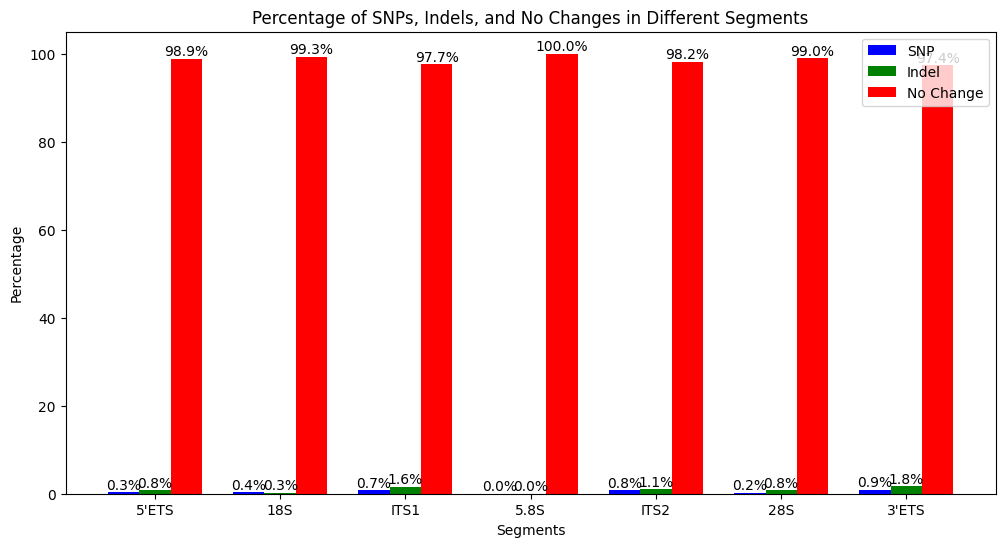

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Spring 2024/Research Fair/Hochwagen/Individual Data/ERR3240115/'

all_positions = [
    [1, 3656, "5'ETS"],
    [3657, 5527, '18S'],
    [5528, 6622, 'ITS1'],
    [6623, 6779, '5.8S'],
    [6780, 7934, 'ITS2'],
    [7935, 12969, '28S'],
    [12970, 13314, "3'ETS"]
]

position_data = {i: {'snp': set(), 'indel': set(), 'no_change': 0} for i in range(1, 13315)}

# Function to parse VCF files and classify SNPs and indels
def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    for _, row in vcf_df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        if len(ref) == len(alt):
            variation = f"{ref}_{alt}"
            position_data[pos]['snp'].add(variation)
        else:
            variation = f"{ref}_{alt}"
            position_data[pos]['indel'].add(variation)
    
    # Track positions with no changes
    all_positions_set = set(range(1, 13315))
    vcf_positions_set = set(vcf_df['POS'].tolist())
    no_change_positions = all_positions_set - vcf_positions_set
    for pos in no_change_positions:
        position_data[pos]['no_change'] += 1

vcf_files = glob.glob(vcf_directory + '*.vcf')
for vcf_file in vcf_files:
    parse_vcf(vcf_file)

segment_data = {label: {'snp': set(), 'indel': set(), 'no_change': 0} for _, _, label in all_positions}

# Count occurrences for each segment
for pos in range(1, 13315):
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_data[label]['snp'].update(position_data[pos]['snp'])
            segment_data[label]['indel'].update(position_data[pos]['indel'])
            segment_data[label]['no_change'] += position_data[pos]['no_change']

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_count = (len(segment_data[label]['snp']) + 
                   len(segment_data[label]['indel']) + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (len(segment_data[label]['snp']) / total_count) * 100
        indel_percentage = (len(segment_data[label]['indel']) / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

segments = list(segment_percentages.keys())
snp_percentages = [segment_percentages[seg]['snp'] for seg in segments]
indel_percentages = [segment_percentages[seg]['indel'] for seg in segments]
no_change_percentages = [segment_percentages[seg]['no_change'] for seg in segments]

# Plotting the histogram
bar_width = 0.25
x = range(len(segments))

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, snp_percentages, color='b', width=bar_width, label='SNP')
bars2 = plt.bar([p + bar_width for p in x], indel_percentages, color='g', width=bar_width, label='Indel')
bars3 = plt.bar([p + bar_width * 2 for p in x], no_change_percentages, color='r', width=bar_width, label='No Change')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of SNPs, Indels, and No Changes in Different Segments')
plt.xticks([p + bar_width for p in x], segments)

plt.legend()

# Adding percentage labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.1f}%', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()

In [8]:
# Calculate overall percentages across the entire dataset
total_snp = sum(len(position_data[pos]['snp']) for pos in range(1, 13315))
total_indel = sum(len(position_data[pos]['indel']) for pos in range(1, 13315))
total_no_change = sum(position_data[pos]['no_change'] for pos in range(1, 13315))
total_positions = 13314

overall_snp_percentage = (total_snp / total_positions) * 100
overall_indel_percentage = (total_indel / total_positions) * 100
overall_no_change_percentage = (total_no_change / total_positions) * 100

# Print overall percentages
print(f"Overall SNP Percentage: {overall_snp_percentage:.2f}%")
print(f"Overall Indel Percentage: {overall_indel_percentage:.2f}%")
print(f"Overall No Change Percentage: {overall_no_change_percentage:.2f}%")

Overall SNP Percentage: 1.67%
Overall Indel Percentage: 1.17%
Overall No Change Percentage: 97.39%


In [9]:
print(segment_data)

{"5'ETS": {'snp': {'G_C', 'C_T', 'A_T', 'G_A', 'T_C', 'C_G', 'A_G', 'A_C', 'T_G', 'C_A'}, 'indel': {'G_GACT', 'CCCGT_C', 'TGAGAC_T', 'TCCCA_T', 'T_TGGCAA', 'T_TGGCC', 'TGCG_T', 'GCTCCC_G', 'C_CG', 'CGG_C', 'C_CCCGT', 'T_TCGCC', 'T_TC', 'CCCGCCCG_C', 'C_CGT', 'A_AC', 'GC_G', 'G_GT', 'GT_G', 'G_GC', 'CCG_C', 'CTCT_C', 'CCCGTCCGCGGCCCGTCCGT_C', 'GGCT_G', 'CT_C', 'GGT_G', 'G_GACC', 'C_CT', 'TG_T'}, 'no_change': 3542}, '18S': {'snp': {'G_C', 'C_T', 'G_T', 'A_G', 'A_T', 'C_A', 'G_A'}, 'indel': {'GC_G', 'AG_A', 'CGG_C', 'CCGTT_C', 'CG_C'}, 'no_change': 1831}, 'ITS1': {'snp': {'C_G', 'C_T', 'A_G', 'A_C', 'T_G', 'C_A', 'G_A', 'A_T'}, 'indel': {'A_AC', 'GGAGAGAGAGAGAGAGAGAGA_G', 'GC_G', 'GGAGAGAGAGAGAGA_G', 'G_GC', 'GCGC_G', 'TGGGC_T', 'TGGGCGGG_T', 'GGGC_G', 'GGAGAGAGAGAGAGAGAGA_G', 'GGGGAGAGAGAGAGAGAGA_G', 'C_CG', 'TGG_T', 'GGC_G', 'GGGGAGAGAGAGAGAGA_G', 'C_CT', 'TG_T'}, 'no_change': 1053}, '5.8S': {'snp': set(), 'indel': set(), 'no_change': 157}, 'ITS2': {'snp': {'G_C', 'C_T', 'T_C', 'C_G', '